# Group Assignment: Time Series Analysis and Modeling using Machine Learning Models
## Dataset: Monthly traffic fatalities in Ontario 1960-1974

In this notebook, we are going to perform a time series analysis of monthly traffic fatalities in Ontario. 
We have structured our work into 4 main parts:
1. Previous Descriptive Analysis and Results
2. Data Preprocessing
3. Model Selection and Fitting
4. Model Validation and Predictive Quality

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
import logging 

# To avoid unnecessary warnings in the final notebook
warnings.filterwarnings("ignore")
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Dictionary to store our predictions
predictions_log = {}

## 1. Previous Descriptive Analysis and Results

### Dataset Description

The dataset contains **monthly traffic fatalities in Ontario, Canada, from January 1960 to December 1974**, covering a 15-year period. It consists of two columns: a date column (monthly frequency) and a fatality count column (`deads`). Upon inspection, **9 non-consecutive months were found missing** from the original 180-month sequence. These gaps were filled using **linear interpolation**, which is appropriate given that the missing months were always isolated and the series exhibits strong, smooth seasonality.

### Key Findings from Exploratory Data Analysis (EDA)

Visual inspection of the raw series revealed three defining characteristics:

- **Upward trend**: Fatalities gradually increase over the 15-year period, likely reflecting the growing number of vehicles on Ontario roads during the 1960s and early 1970s.
- **Annual seasonality**: A clear 12-month cyclical pattern is visible, with peaks in summer months (holiday travel) and troughs in winter.
- **Increasing variance**: The amplitude of seasonal cycles grows over time, suggesting multiplicative rather than purely additive behavior.

The **Augmented Dickey-Fuller (ADF) test** confirmed that the original series is **non-stationary** (p-value = 0.222, failing to reject the unit root hypothesis).

### Preprocessing and Stationarity

To address the increasing variance, a **logarithmic transformation** was applied to stabilize it. This choice was supported by **Guerrero's method**, which estimated an optimal Box-Cox lambda of −0.1 (close to 0, i.e., log), while MLE suggested 0.5; the log transformation was preferred for its interpretability.

Additive seasonal decomposition of the log-transformed series confirmed the presence of a clear upward trend and a stable, regular seasonal component. To achieve stationarity — a requirement for classical time series models — the series was **differenced twice**: once at lag 1 (d=1) to remove the trend, and once at lag 12 (D=1) to remove the seasonal component. After both differences, the ADF test confirmed stationarity (p-value = 0.0005).

### Statistical Model: SARIMA(1,1,1)(2,1,0)[12]

Using **AutoARIMA** with AIC as the selection criterion, the best model identified was **SARIMA(1,1,1)(2,1,0)[12]**, fitted on the log-transformed series with a **train/test split of 156/24 months** (last 24 months reserved for evaluation).

**Residual diagnostics** indicated a well-fitted model:
- The **Ljung-Box test** (p = 0.051) narrowly confirmed the absence of residual autocorrelation.
- The **Shapiro-Wilk test** flagged non-normality, but QQ-plot inspection revealed this was driven by only two isolated outliers at the tails — not a structural model deficiency.

**Predictive performance on the test set (original scale, after reversing the log transform):**

| Metric | Value |
|--------|-------|
| RMSE   | 28.66 |
| MAE    | 23.52 |
| MAPE   | 16.31% |

The model successfully captured the seasonal pattern of summer peaks and winter troughs. A MAPE of ~16% represents a reasonable baseline for a dataset with notable volatility, and will serve as the **benchmark to beat** in this second assessment using machine learning approaches.

Train set size: 156
Test set size: 24


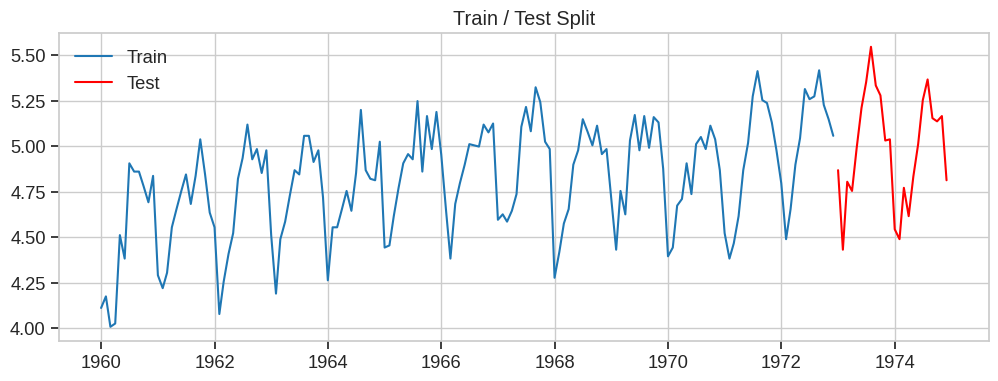

In [2]:
# Load data
file_path = 'data/10_Monthly traffic fatalities in Ontario 1960-1974.csv'
df = pd.read_csv(file_path)

# Convert to datetime
df['date'] = pd.to_datetime(df['date'])

# Set date as the index
df.set_index('date', inplace=True)

# Resample to a monthly frequency from start to end
df = df.resample('MS').asfreq()

df_resampled = df.copy()

# Imputation of missing values using time interpolation
df_resampled['deads'] = df_resampled['deads'].interpolate(method='linear')

# Logarithmic transformation to stabilize variance
df_resampled['log_deads'] = np.log(df_resampled['deads'])

# Train-Test Split (last 24 months as Test)
train_size = len(df_resampled) - 24
train, test = df_resampled['log_deads'].iloc[:train_size], df_resampled['log_deads'].iloc[train_size:]

print(f"Train set size: {len(train)}")
print(f"Test set size: {len(test)}")

plt.figure(figsize=(12, 4))
plt.plot(train, label='Train')
plt.plot(test, label='Test', color='red')
plt.legend()
plt.title('Train / Test Split')
plt.show()

### SARIMA baseline:


SARIMA(1,1,1)(2,1,0)[12] Summary
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1556      0.098      1.582      0.114      -0.037       0.348
ma.L1         -0.9096      0.053    -17.076      0.000      -1.014      -0.805
ar.S.L12      -0.5243      0.103     -5.078      0.000      -0.727      -0.322
ar.S.L24      -0.3179      0.092     -3.437      0.001      -0.499      -0.137
sigma2         0.0241      0.003      7.870      0.000       0.018       0.030


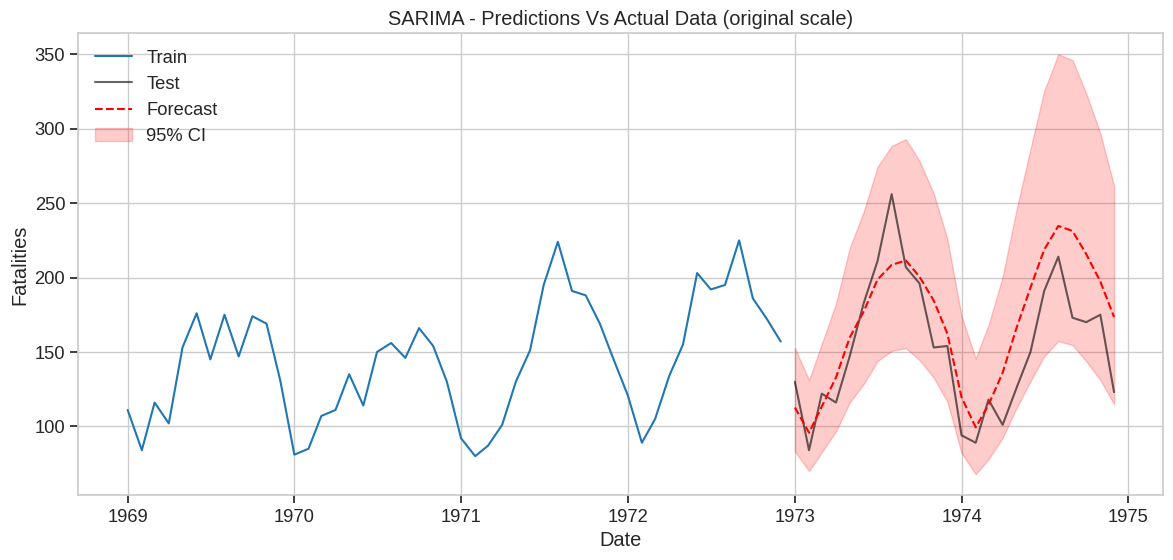

Forecast Accuracy Metrics:
  RMSE: 28.66
  MAE:  23.52
  MAPE: 16.31%
  MPIW: 124.84



In [3]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Model Specification
# order=(p,d,q) | seasonal_order=(P,D,Q,m)
model_sarima = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(2, 1, 0, 12),
    enforce_stationarity=True,
    enforce_invertibility=False
)

# Parameter Estimation (Fitting)
results_sarima = model_sarima.fit(disp=False)

print("\nSARIMA(1,1,1)(2,1,0)[12] Summary")
print("="*60)
print(results_sarima.summary().tables[1]) # Display Coefficient Table

# Forecasting
# Generate forecasts for the test period
steps = len(test)
forecast_res = results_sarima.get_forecast(steps=steps)
pred_mean = np.exp(forecast_res.predicted_mean)
pred_ci = np.exp(forecast_res.conf_int())

# Visualization
plt.figure(figsize=(14, 6))

train_real = np.exp(train)
test_real = np.exp(test)

plt.plot(train_real.index[-48:], train_real[-48:], label='Train')
plt.plot(test_real.index, test_real, label='Test', color='black', alpha=0.6)
plt.plot(test_real.index, pred_mean, label='Forecast', color='red', linestyle='--')

# Confidence interval
plt.fill_between(test_real.index, 
                 pred_ci.iloc[:, 0], 
                 pred_ci.iloc[:, 1], 
                 color='red', alpha=0.2, label='95% CI')

plt.title('SARIMA - Predictions Vs Actual Data (original scale)')
plt.xlabel('Date')
plt.ylabel('Fatalities')
plt.legend()
plt.show()

# Metrics
rmse = np.sqrt(mean_squared_error(test_real, pred_mean))
mae = mean_absolute_error(test_real, pred_mean)
mape = mean_absolute_percentage_error(test_real, pred_mean)
mpiw = (pred_ci.iloc[:, 1].values - pred_ci.iloc[:, 0].values).mean()

stats_dict = {
    "prediction": pred_mean.values,
    "lower_bound": pred_ci.iloc[:, 0].values,
    "upper_bound": pred_ci.iloc[:, 1].values,
    "rmse": rmse,
    "mae": mae,
    "mape": mape,
    "mpiw": mpiw
}

predictions_log["SARIMA_baseline"] = stats_dict

print(f"Forecast Accuracy Metrics:")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE:  {mae:.2f}")
print(f"  MAPE: {mape * 100:.2f}%")
print(f"  MPIW: {mpiw:.2f}\n")

## 2. Data Preprocessing for Machine Learning

To apply Machine Learning models, we must transform the time series into a supervised learning problem. We will:

1. **Impute Missing Values**: Use linear interpolation to handle the 9 isolated missing months.
2. **Feature Engineering**: Extract temporal and lag/rolling features to capture trend and seasonality (detailed below).
3. **Train-Test Split**: Chronologically split the data, holding out the last 24 months for testing.

---

### Feature Engineering Decisions

#### Temporal Features — Fourier Encoding
Raw calendar values like `month` (1–12) are ordinal but not cyclic: a naive model would treat January (1) and December (12) as far apart, when in reality they are adjacent. To fix this, we encode `month` and `quarter` using **first-order Fourier harmonics** (one sine/cosine pair each), which maps them onto the unit circle so that the distance between any two consecutive periods is uniform — including the wrap-around from December back to January.

#### Lag Features
We include lags at **t−1, t−2, t−3** and **t−12**:
- **t−1, t−2, t−3** give the model a short memory of recent months, which is important since consecutive mortality counts may be correlated.
- **t−12** directly captures the yearly seasonal pattern: the value from the same month one year ago is the single strongest predictor of the current value in most annual cycles.

#### Rolling Statistics
All rolling features are computed on `lag_1` rather than on the raw target, ensuring **no data leakage** into the current time step.

| Feature | Window | Purpose |
|---|---|---|
| `rolling_mean_3`, `rolling_std_3` | 3 months | Short-term trend and local volatility |
| `rolling_mean_12`, `rolling_std_12` | 12 months | Long-term trend and annual-scale volatility |
| `min_4`, `max_4` | 4 months | Short-term range — flags sudden spikes or drops |
| `min_12`, `max_12` | 12 months | Long-term range — flags structural shifts or anomalies |

Finally, any rows with `NaN` values introduced by the shift and rolling operations are dropped before modelling.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def create_fourier_features(df, period, order):
    """
    Generates Fourier basis functions (X variables) for a given periodicity.
    
    Parameters
    ----------
    df : pd.DataFrame
        Input data with a DatetimeIndex.
    period : int
        The fundamental period of the cycle (P).
    order : int
        The number of harmonic pairs (K) to generate.
    """
    result = df.copy()
    
    # We use an integer sequence for 't' to represent the time step
    t = np.arange(len(result))
    
    for k in range(1, order + 1):
        # Angular frequency omega
        omega = 2 * np.pi * k / period
        
        # We generate the unweighted waves. 
        # The model will later assign weights to these columns.
        result[f'sin_{k}'] = np.sin(omega * t)
        result[f'cos_{k}'] = np.cos(omega * t)
    
    return result

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

df_ml = df.copy()

# Impute missing values using linear interpolation
df_ml['deads'] = df_ml['deads'].interpolate(method='linear')

# Feature Engineering
# Temporal Features
df_ml['month'] = df_ml.index.month
df_ml['quarter'] = df_ml.index.quarter

df_ml['month_sin_1'] = create_fourier_features(df_ml['month'], period=12, order=1)["sin_1"]
df_ml['month_cos_1'] = create_fourier_features(df_ml['month'], period=12, order=1)["cos_1"]
df_ml['quarter_sin_1'] = create_fourier_features(df_ml['quarter'], period=12, order=1)["sin_1"]
df_ml['quarter_cos_1'] = create_fourier_features(df_ml['quarter'], period=12, order=1)["cos_1"]

# Lag Features (t-1, t-2, t-3, t-12)
df_ml['lag_1'] = df_ml['deads'].shift(1)
df_ml['lag_2'] = df_ml['deads'].shift(2)
df_ml['lag_3'] = df_ml['deads'].shift(3)
df_ml['lag_12'] = df_ml['deads'].shift(12)

# Rolling Statistics (on lag_1 so we don't leak current target)
df_ml['rolling_mean_3'] = df_ml['lag_1'].rolling(window=3).mean()
df_ml['rolling_std_3'] = df_ml['lag_1'].rolling(window=3).std()
df_ml['rolling_mean_12'] = df_ml['lag_1'].rolling(window=12).mean()
df_ml['rolling_std_12'] = df_ml['lag_1'].rolling(window=12).std()

df_ml['min_4'] = df_ml['lag_1'].rolling(window=4).min()
df_ml['max_4'] = df_ml['lag_1'].rolling(window=4).max()
df_ml['min_12'] = df_ml['lag_1'].rolling(window=12).min()
df_ml['max_12'] = df_ml['lag_1'].rolling(window=12).max()

# Drop NaN values caused by shifts and rolling computations
df_ml = df_ml.dropna()

df_ml.head()

,deads,month,quarter,month_sin_1,month_cos_1,quarter_sin_1,quarter_cos_1,lag_1,lag_2,lag_3,lag_12,rolling_mean_3,rolling_std_3,rolling_mean_12,rolling_std_12,min_4,max_4,min_12,max_12
date,,,,,,,,,,,,,,,,,,,
1961-01-01,73.0,1,1,-2.449294e-16,1.000000e+00,-2.449294e-16,1.000000e+00,126.0,109.0,119.0,61.0,118.000000,8.544004,96.250000,31.686318,109.0,129.0,55.0,135.0
1961-02-01,68.0,2,1,5.000000e-01,8.660254e-01,5.000000e-01,8.660254e-01,73.0,126.0,109.0,65.0,102.666667,27.061658,97.250000,30.644961,73.0,126.0,55.0,135.0
1961-03-01,74.0,3,1,8.660254e-01,5.000000e-01,8.660254e-01,5.000000e-01,68.0,73.0,126.0,55.0,89.000000,32.140317,97.500000,30.368943,68.0,126.0,55.0,135.0
1961-04-01,95.0,4,2,1.000000e+00,1.194340e-15,1.000000e+00,1.194340e-15,74.0,68.0,73.0,56.0,71.666667,3.214550,99.083333,28.381999,68.0,126.0,56.0,135.0
1961-05-01,105.0,5,2,8.660254e-01,-5.000000e-01,8.660254e-01,-5.000000e-01,95.0,74.0,68.0,91.0,79.000000,14.177447,102.333333,25.035732,68.0,95.0,68.0,135.0


### 2.1 Data Splitting and Scaling
We split chronologically. The last 24 months are our test set.

In [6]:
from sklearn.preprocessing import StandardScaler

test_size = 24
train_df = df_ml.iloc[:-test_size].copy()
test_df = df_ml.iloc[-test_size:].copy()

# Define features and target
features = df_ml.columns[1:]
target = 'deads'

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (144, 18)
Test set shape: (24, 18)


## 3. Model Selection and Fitting

We benchmark a diverse set of models spanning different learning paradigms, so that we can assess which inductive biases best suit the structure of this time series (trend, seasonality, and potential non-linearities).

1. **Ridge Regression**: Regularised linear baseline — tests whether the engineered features alone are sufficient to explain the signal.
2. **XGBoost**: Gradient boosting method — captures non-linearities and feature interactions that a linear model would miss.
3. **MLP Regressor**: Shallow neural network — offers a different generalisation profile from tree-based methods, better suited to smooth and continuous patterns.
4. **Prophet**: Additive decomposition model — operates directly on the time index rather than lag features, providing a structurally distinct point of comparison.

> **Forecasting strategy**: all models are evaluated using **6-step-ahead validation** on the held-out test set. This horizon is a deliberate compromise: short enough to prevent error from accumulating excessively across recursive steps, yet long enough to provide sufficient evaluation points so that performance on distant forecasts does not rely on too few observations.

In [7]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from skforecast.model_selection import grid_search_forecaster, TimeSeriesFold

from skforecast.recursive import ForecasterRecursive
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import Ridge, Lasso
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


### Linear Regression

lags grid:   0%|          | 0/1 [00:00<?, ?it/s]

params grid:   0%|          | 0/10 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [1 2 3 4 5 6] 
  Parameters: {'ridge__alpha': 10.0}
  Backtesting metric: 406.9273108437496
Grid Search Results (Top 3):
                 lags          lags_label  \
0  [1, 2, 3, 4, 5, 6]  [1, 2, 3, 4, 5, 6]   
1  [1, 2, 3, 4, 5, 6]  [1, 2, 3, 4, 5, 6]   
2  [1, 2, 3, 4, 5, 6]  [1, 2, 3, 4, 5, 6]   

                                 params  mean_squared_error  \
0                {'ridge__alpha': 10.0}          406.927311   
1   {'ridge__alpha': 2.154434690031882}          413.426458   
2  {'ridge__alpha': 0.4641588833612777}          423.028467   

   mean_absolute_error  mean_absolute_percentage_error  ridge__alpha  
0            13.682205                        0.091558     10.000000  
1            13.891769                        0.092943      2.154435  
2            14.166145                        0.094638      0.464159  
Best lambda value: 10.0

Forecast Accuracy Metrics:
  RMSE: 4.90

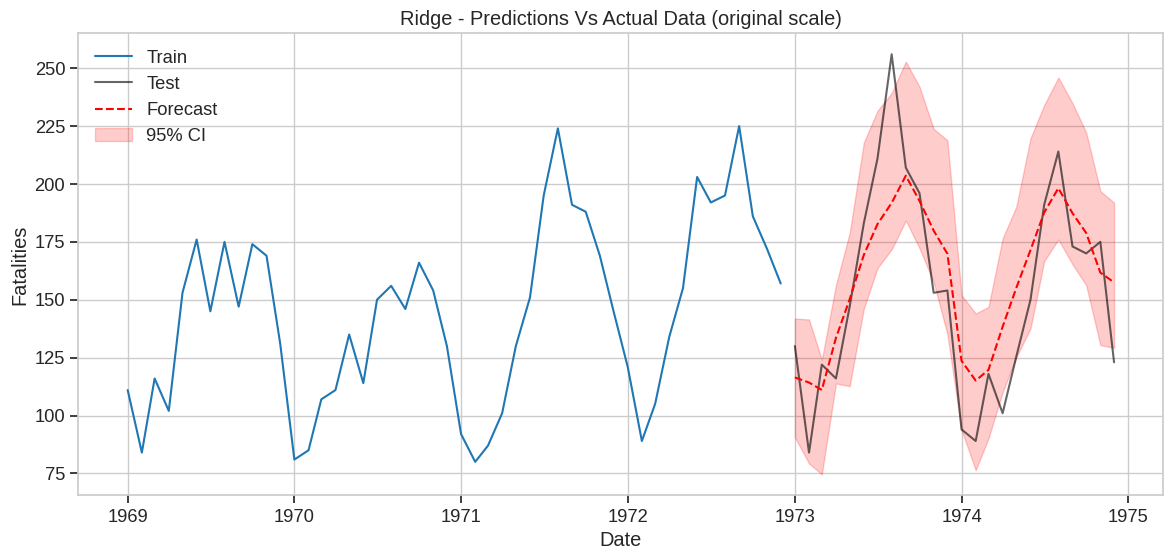

In [8]:
steps_test = len(test)

# Define the Pipeline and Forecaster
pipe = make_pipeline(StandardScaler(), Ridge())
forecaster = ForecasterRecursive(regressor=pipe, lags=6)

# Define the Search Grid (Logarithmic Scale)
# This creates 10 values from 10^-3 (0.001) to 10^3 (1000)
param_grid = {
    'ridge__alpha': np.logspace(-3, 3, 10)
}

# Define Cross-Validation Strategy with TimeSeriesFold
cv = TimeSeriesFold(
    steps              = steps_test, # Forecasting horizon for validation
    initial_train_size = len(y_train) - 36, # Sub-train size
    fold_stride        = 12, # steps the sliding window moves forward (by default = steps)
    refit              = True, # Refit model at each fold (=False: no refit; =3: more efficient refit each 3 steps)
    fixed_train_size   = False,              # Expanding window
    gap                = 0,                  # No gap between train and test
    allow_incomplete_fold = True
)

# Run Grid Search with Backtesting
results_grid = grid_search_forecaster(
    forecaster    = forecaster,
    y             = y_train,
    exog          = X_train,
    param_grid    = param_grid,
    cv            = cv,                      
    metric        = ['mean_squared_error', 'mean_absolute_error', 'mean_absolute_percentage_error'],
    return_best   = True, # Keeps the best model in the forecaster object
    n_jobs        = 'auto', #parallel evaluation if more cores ar available
    verbose       = False,
    show_progress = True
)

print("Grid Search Results (Top 3):")
print(results_grid.head(3))
print(f"Best lambda value: {results_grid.iloc[0].ridge__alpha}")

# Final Prediction on Test Set
# Since refit=True, 'forecaster' now holds the best alpha and is trained on y_train
predictions_df = forecaster.predict_interval(steps=24, exog=X_test, interval=[2.5, 97.5])

# Calculate and save metrics
predictions = predictions_df['pred']
lower_bound = predictions_df['lower_bound'] 
upper_bound = predictions_df['upper_bound'] 

rmse_ridge = np.sqrt(mean_squared_error(y_test, predictions))
mae_ridge = mean_absolute_error(y_test, predictions)
mape_ridge = mean_absolute_percentage_error(y_test, predictions)
mpiw_ridge = (upper_bound - lower_bound).mean()

stats_dict = {
    "prediction": predictions.values,
    "lower_bound": lower_bound.values,
    "upper_bound": upper_bound.values,
    "rmse": rmse_ridge,
    "mae": mae_ridge,
    "mape": mape_ridge,
    "mpiw": mpiw_ridge
}

predictions_log["Ridge"] = stats_dict

print(f"\nForecast Accuracy Metrics:")
print(f"  RMSE: {np.sqrt(rmse_ridge):.2f}")
print(f"  MAE: {mae_ridge:.2f}")
print(f"  MAPE: {(mape_ridge) * 100:.2f}%")
print(f"  MPIW: {mpiw_ridge:.2f}\n")

# Visualization
plt.figure(figsize=(14, 6))

plt.plot(X_train.index[-48:], y_train.iloc[-48:], label='Train')

plt.plot(X_test.index, y_test, label='Test', color='black', alpha=0.6)
plt.plot(X_test.index, predictions, label='Forecast', color='red', linestyle='--')

# Confidence interval
plt.fill_between(test_real.index, 
                 lower_bound, 
                 upper_bound, 
                 color='red', alpha=0.2, label='95% CI')

plt.title('Ridge - Predictions Vs Actual Data (original scale)')
plt.xlabel('Date')
plt.ylabel('Fatalities')
plt.legend()
plt.show()

Looks like the Linear Regression model captures the time series behaviour even better than the SARIMA baseline. The obtained error values are smaller and the confidence interval is around 2 times thinner.

### XGBoost

lags grid:   0%|          | 0/1 [00:00<?, ?it/s]

params grid:   0%|          | 0/243 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [1 2 3 4 5 6] 
  Parameters: {'xgbregressor__learning_rate': 0.1, 'xgbregressor__max_depth': 5, 'xgbregressor__n_estimators': 100, 'xgbregressor__reg_alpha': 0, 'xgbregressor__reg_lambda': 0}
  Backtesting metric: 537.4101690082348
Grid Search Results (Top 3):
                 lags          lags_label  \
0  [1, 2, 3, 4, 5, 6]  [1, 2, 3, 4, 5, 6]   
1  [1, 2, 3, 4, 5, 6]  [1, 2, 3, 4, 5, 6]   
2  [1, 2, 3, 4, 5, 6]  [1, 2, 3, 4, 5, 6]   

                                              params  mean_squared_error  \
0  {'xgbregressor__learning_rate': 0.1, 'xgbregre...          537.410169   
1  {'xgbregressor__learning_rate': 0.1, 'xgbregre...          542.881038   
2  {'xgbregressor__learning_rate': 0.1, 'xgbregre...          566.125588   

   mean_absolute_error  mean_absolute_percentage_error  \
0            16.486875                        0.116863   
1            16.568122                  

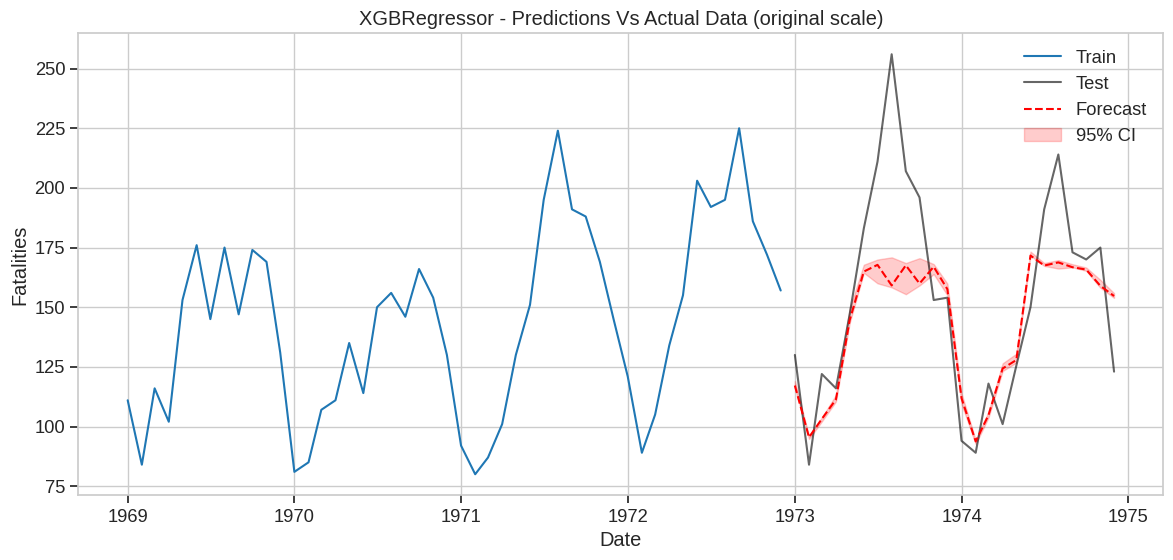

In [9]:
steps_test = len(test)

# Define the Pipeline and Forecaster
xgb_regressor = XGBRegressor(
    random_state=42
)

pipe = make_pipeline(StandardScaler(), xgb_regressor)
forecaster = ForecasterRecursive(regressor=pipe, lags=6)

# Define the Search Grid
param_grid = {
    'xgbregressor__n_estimators': [50, 100, 200],
    'xgbregressor__max_depth': [1, 5, 10],
    'xgbregressor__learning_rate': [0.01, 0.05, 0.1],
    'xgbregressor__reg_alpha': [0, 1, 10],
    'xgbregressor__reg_lambda': [0, 1, 10]
}

# Define Cross-Validation Strategy with TimeSeriesFold
cv = TimeSeriesFold(
    steps              = steps_test, # Forecasting horizon for validation
    initial_train_size = len(y_train) - 36, # Sub-train size
    fold_stride        = 12, # steps the sliding window moves forward (by default = steps)
    refit              = True, # Refit model at each fold (=False: no refit; =3: more efficient refit each 3 steps)
    fixed_train_size   = False,              # Expanding window
    gap                = 0,                  # No gap between train and test
    allow_incomplete_fold = True
)

# Run Grid Search with Backtesting
results_grid = grid_search_forecaster(
    forecaster    = forecaster,
    y             = y_train,
    exog          = X_train,
    param_grid    = param_grid,
    cv            = cv,                      
    metric        = ['mean_squared_error', 'mean_absolute_error', 'mean_absolute_percentage_error'],
    return_best   = True, # Keeps the best model in the forecaster object
    n_jobs        = 'auto', #parallel evaluation if more cores ar available
    verbose       = False,
    show_progress = True
)

print("Grid Search Results (Top 3):")
print(results_grid.head(3))

print(f"Best #Estimators: {results_grid.iloc[0].xgbregressor__n_estimators}")
print(f"Best Max Depth: {results_grid.iloc[0].xgbregressor__max_depth}")
print(f"Best Learning Rate: {results_grid.iloc[0].xgbregressor__learning_rate}")
print(f"Best Alpha: {results_grid.iloc[0].xgbregressor__reg_alpha}")
print(f"Best Lambda: {results_grid.iloc[0].xgbregressor__reg_lambda}")

# Final Prediction on Test Set
# Since refit=True, 'forecaster' now holds the best alpha and is trained on y_train
predictions_df = forecaster.predict_interval(steps=24, exog=X_test, interval=[2.5, 97.5])

# Compute and save metrics
predictions = predictions_df['pred']
lower_bound = predictions_df['lower_bound'] 
upper_bound = predictions_df['upper_bound'] 

rmse_xgb = np.sqrt(mean_squared_error(y_test, predictions))
mae_xgb = mean_absolute_error(y_test, predictions)
mape_xgb = mean_absolute_percentage_error(y_test, predictions)
mpiw_xgb = (upper_bound - lower_bound).mean()

stats_dict = {
    "prediction": predictions.values,
    "lower_bound": lower_bound.values,
    "upper_bound": upper_bound.values,
    "rmse": rmse_xgb,
    "mae": mae_xgb,
    "mape": mape_xgb,
    "mpiw": mpiw_xgb
}

predictions_log["XGB_Regressor"] = stats_dict

print(f"\nForecast Accuracy Metrics:")
print(f"  RMSE: {np.sqrt(rmse_xgb):.2f}")
print(f"  MAE: {mae_xgb:.2f}")
print(f"  MAPE: {(mape_xgb) * 100:.2f}%")
print(f"  MPIW: {mpiw_xgb:.2f}\n")

# Visualization
plt.figure(figsize=(14, 6))

plt.plot(X_train.index[-48:], y_train.iloc[-48:], label='Train')
plt.plot(X_test.index, y_test, label='Test', color='black', alpha=0.6)
plt.plot(X_test.index, predictions, label='Forecast', color='red', linestyle='--')

# Confidence interval
plt.fill_between(test_real.index, 
                 lower_bound, 
                 upper_bound, 
                 color='red', alpha=0.2, label='95% CI')

plt.title('XGBRegressor - Predictions Vs Actual Data (original scale)')
plt.xlabel('Date')
plt.ylabel('Fatalities')
plt.legend()
plt.show()

Even if the model fails on summer months, the prediction fits really well on the rest of the year. The obtained errors are better than the baseline and there is almost no uncertainity on the confidence interval. The reason behind the summer failure may be that the model fitted too much to the data before 1971 and didn't capture the increasing variance of the last two years.

### MLP

lags grid:   0%|          | 0/1 [00:00<?, ?it/s]

params grid:   0%|          | 0/36 [00:00<?, ?it/s]

/home/alumno/Desktop/datos/Time Series/TS_Assignment_2/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (9000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/alumno/Desktop/datos/Time Series/TS_Assignment_2/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (9000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/alumno/Desktop/datos/Time Series/TS_Assignment_2/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (9000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/alumno/Desktop/datos/Time Series/TS_Assignment_2/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: 

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [1 2 3 4 5 6] 
  Parameters: {'mlpregressor__activation': 'relu', 'mlpregressor__alpha': 1, 'mlpregressor__hidden_layer_sizes': (32, 16), 'mlpregressor__learning_rate_init': 0.001}
  Backtesting metric: 374.37809835225005
Grid Search Results (Top 3):
                 lags          lags_label  \
0  [1, 2, 3, 4, 5, 6]  [1, 2, 3, 4, 5, 6]   
1  [1, 2, 3, 4, 5, 6]  [1, 2, 3, 4, 5, 6]   
2  [1, 2, 3, 4, 5, 6]  [1, 2, 3, 4, 5, 6]   

                                              params  mean_squared_error  \
0  {'mlpregressor__activation': 'relu', 'mlpregre...          374.378098   
1  {'mlpregressor__activation': 'relu', 'mlpregre...          417.223245   
2  {'mlpregressor__activation': 'relu', 'mlpregre...          454.836007   

   mean_absolute_error  mean_absolute_percentage_error  \
0            14.313673                        0.094550   
1            13.858513                        0.09

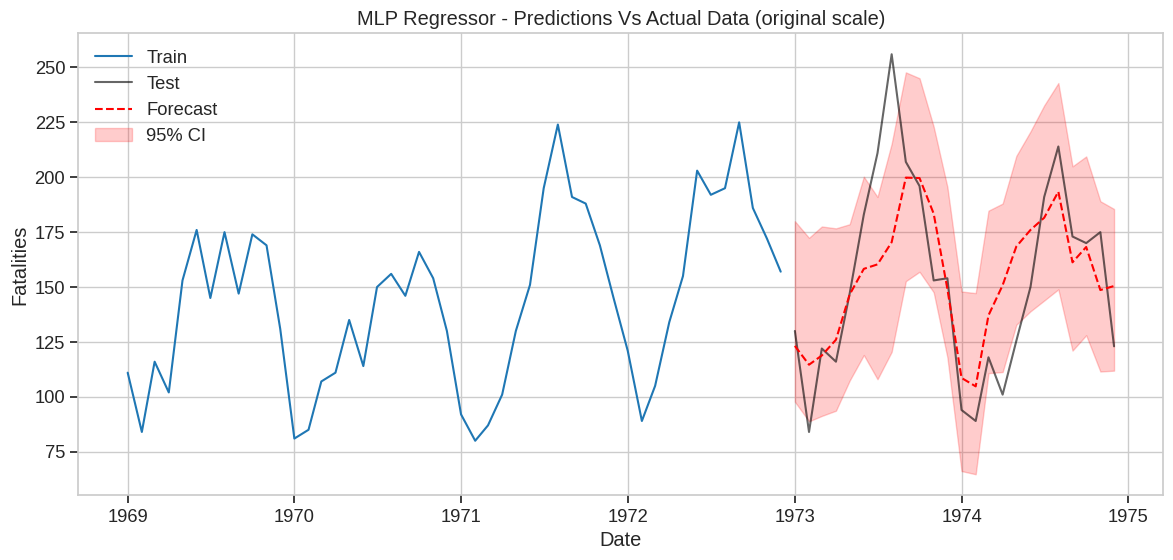

In [10]:
steps_test = len(test)

# Define the Pipeline and Forecaster
mlp_regressor = MLPRegressor(     
    solver='adam',               
    max_iter=9000,
    early_stopping=True,         
    random_state=42
)

pipe = make_pipeline(StandardScaler(), mlp_regressor)
forecaster = ForecasterRecursive(regressor=pipe, lags=6)

# Define the Search Grid
param_grid = {
    'mlpregressor__hidden_layer_sizes': [(32, 16), (64, 32), (64, 32, 16)],
    'mlpregressor__activation': ['relu', 'tanh'],
    'mlpregressor__learning_rate_init': [0.0001, 0.001],
    'mlpregressor__alpha': [0, 1, 10]
}

# Define Cross-Validation Strategy with TimeSeriesFold
cv = TimeSeriesFold(
    steps              = steps_test, # Forecasting horizon for validation
    initial_train_size = len(y_train) - 36, # Sub-train size
    fold_stride        = 12, # steps the sliding window moves forward (by default = steps)
    refit              = True, # Refit model at each fold (=False: no refit; =3: more efficient refit each 3 steps)
    fixed_train_size   = False,              # Expanding window
    gap                = 0,                  # No gap between train and test
    allow_incomplete_fold = True
)

# Run Grid Search with Backtesting
results_grid = grid_search_forecaster(
    forecaster    = forecaster,
    y             = y_train,
    exog          = X_train,
    param_grid    = param_grid,
    cv            = cv,                      
    metric        = ['mean_squared_error', 'mean_absolute_error', 'mean_absolute_percentage_error'],
    return_best   = True, # Keeps the best model in the forecaster object
    n_jobs        = 'auto', #parallel evaluation if more cores ar available
    verbose       = False,
    show_progress = True
)

print("Grid Search Results (Top 3):")
print(results_grid.head(3))

print(f"Best Hidden Layers Configuration: {results_grid.iloc[0].mlpregressor__hidden_layer_sizes}")
print(f"Best Activation: {results_grid.iloc[0].mlpregressor__activation}")
print(f"Best Learning Rate Initialization: {results_grid.iloc[0].mlpregressor__learning_rate_init}")
print(f"Best Alpha: {results_grid.iloc[0].mlpregressor__alpha}")

# Final Prediction on Test Set
# Since refit=True, 'forecaster' now holds the best alpha and is trained on y_train
predictions_df = forecaster.predict_interval(steps=24, exog=X_test, interval=[2.5, 97.5])

# Compute and save metrics
predictions = predictions_df['pred']
lower_bound = predictions_df['lower_bound'] 
upper_bound = predictions_df['upper_bound'] 

rmse_mlp = np.sqrt(mean_squared_error(y_test, predictions))
mae_mlp = mean_absolute_error(y_test, predictions)
mape_mlp = mean_absolute_percentage_error(y_test, predictions)
mpiw_mlp = (upper_bound - lower_bound).mean()

stats_dict = {
    "prediction": predictions.values,
    "lower_bound": lower_bound.values,
    "upper_bound": upper_bound.values,
    "rmse": rmse_mlp,
    "mae": mae_mlp,
    "mape": mape_mlp,
    "mpiw": mpiw_mlp
}

predictions_log["MLP_Regressor"] = stats_dict

print(f"\nForecast Accuracy Metrics:")
print(f"  RMSE: {np.sqrt(rmse_mlp):.2f}")
print(f"  MAE: {mae_mlp:.2f}")
print(f"  MAPE: {(mape_mlp) * 100:.2f}%")
print(f"  MPIW: {mpiw_mlp:.2f}\n")

# Visualization
plt.figure(figsize=(14, 6))

plt.plot(X_train.index[-48:], y_train.iloc[-48:], label='Train')
plt.plot(X_test.index, y_test, label='Test', color='black', alpha=0.6)
plt.plot(X_test.index, predictions, label='Forecast', color='red', linestyle='--')

# Confidence interval
plt.fill_between(test_real.index, 
                 lower_bound, 
                 upper_bound, 
                 color='red', alpha=0.2, label='95% CI')

plt.title('MLP Regressor - Predictions Vs Actual Data (original scale)')
plt.xlabel('Date')
plt.ylabel('Fatalities')
plt.legend()
plt.show()

Here again, we obtain better results that the baseline, but they aren't that good as the previous models' results.

### Prophet

22:39:02 - cmdstanpy - INFO - Chain [1] start processing
22:39:02 - cmdstanpy - INFO - Chain [1] done processing
22:39:02 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
22:39:02 - cmdstanpy - INFO - Chain [1] start processing
22:39:02 - cmdstanpy - INFO - Chain [1] done processing
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
22:39:03 - cmdstanpy - INFO - Chain [1] start processing
22:39:03 - cmdstanpy - INFO - Chain [1] start processing
22:39:03 - cmdstanpy - INFO - Chain [1] done processing
22:39:03 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
22:39:03 - cmdstanpy - INFO - Chain [1] done processing
22:39:03 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
22:39:03 

Grid Search Results (Top 3):
    changepoint_prior_scale  seasonality_prior_scale seasonality_mode  \
15                    0.010                     10.0   multiplicative   
5                     0.001                      1.0   multiplicative   
3                     0.001                      0.1   multiplicative   

          mae         mse      mape  
15  17.129914  442.294921  0.126200  
5   17.826295  551.496545  0.130428  
3   17.892522  481.043538  0.131336  

Best params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'multiplicative'}

Forecast Accuracy Metrics:
  RMSE: 22.97
  MAE:  18.56
  MAPE: 13.08%
  MPIW: 45.07



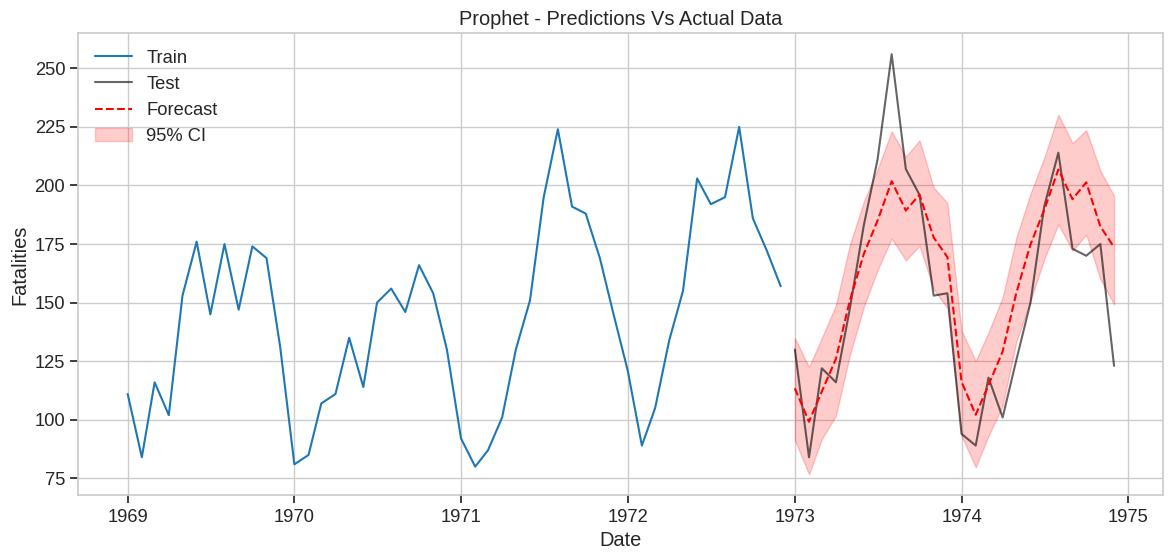

In [11]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import itertools

# Data in Prophet format
df_prophet_train = pd.DataFrame({
    'ds': df_ml.index[:-test_size],
    'y':  df_ml['deads'].values[:-test_size]
})

y_test_prophet = df_ml['deads'].values[-test_size:]
y_test_index   = df_ml.index[-test_size:]

# Grid Search
param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    'seasonality_mode':        ['additive', 'multiplicative'],
}

all_params = [dict(zip(param_grid.keys(), v)) 
              for v in itertools.product(*param_grid.values())]

# Grid Search with cross-validation
# We convert months to days (Prophet works with days)
initial_days = (len(df_prophet_train) - 36) * 30  # equiv. len(y_train) - 36
period_days  = 12 * 30                             # equiv. fold_stride=12 months
horizon_days = test_size * 30                      # equiv. steps_test=24 months

results = []
for params in all_params:
    model = Prophet(
        yearly_seasonality = True,
        weekly_seasonality = False,
        daily_seasonality  = False,
        **params
    )
    model.fit(df_prophet_train)
    
    df_cv = cross_validation(
        model,
        initial  = f'{initial_days} days',
        period   = f'{period_days} days',
        horizon  = f'{horizon_days} days',
        parallel = 'processes'
    )
    
    df_perf = performance_metrics(df_cv, rolling_window=1)
    results.append({
        **params,
        'mae':  df_perf['mae'].mean(),
        'mse':  df_perf['mse'].mean(),
        'mape': df_perf['mape'].mean(),
    })

# Best parameters
results_df  = pd.DataFrame(results).sort_values('mae')
best_params = results_df.iloc[0][list(param_grid.keys())].to_dict()

print("Grid Search Results (Top 3):")
print(results_df.head(3))
print(f"\nBest params: {best_params}")

# Refit
best_model = Prophet(
    yearly_seasonality = True,
    weekly_seasonality = False,
    daily_seasonality  = False,
    **best_params
)
best_model.fit(df_prophet_train)

# Prediction
future   = best_model.make_future_dataframe(periods=test_size, freq='MS')
forecast = best_model.predict(future)
predictions = forecast.tail(test_size)

preds = predictions['yhat'].values
lower = predictions['yhat_lower'].values
upper = predictions['yhat_upper'].values

# Metrics
rmse_prophet = np.sqrt(mean_squared_error(y_test_prophet, preds))
mae_prophet  = mean_absolute_error(y_test_prophet, preds)
mape_prophet = mean_absolute_percentage_error(y_test_prophet, preds)
mpiw_prophet = (upper - lower).mean()

stats_dict = {
    "prediction": preds,
    "lower_bound": lower,
    "upper_bound": upper,
    "rmse": rmse_prophet,
    "mae": mae_prophet,
    "mape": mape_prophet,
    "mpiw": mpiw_prophet
}

predictions_log['Prophet'] = stats_dict

print(f"\nForecast Accuracy Metrics:")
print(f"  RMSE: {rmse_prophet:.2f}")
print(f"  MAE:  {mae_prophet:.2f}")
print(f"  MAPE: {mape_prophet * 100:.2f}%")
print(f"  MPIW: {mpiw_prophet:.2f}\n")

# Visualization
plt.figure(figsize=(14, 6))
plt.plot(df_prophet_train['ds'].iloc[-48:], df_prophet_train['y'].iloc[-48:], label='Train')
plt.plot(y_test_index, y_test_prophet, label='Test', color='black', alpha=0.6)
plt.plot(y_test_index, preds, label='Forecast', color='red', linestyle='--')
plt.fill_between(y_test_index, lower, upper, color='red', alpha=0.2, label='95% CI')
plt.title('Prophet - Predictions Vs Actual Data')
plt.xlabel('Date')
plt.ylabel('Fatalities')
plt.legend()
plt.show()

The results obtained by Prophet are better than the SARIMA baseline and they are also quite impressing if we take into account that it didn't use exogenous variables as previous ML models.

## 4. Model Validation and Predictive Quality

We evaluate each model using three complementary error metrics:

- **MAE** (Mean Absolute Error)
- **RMSE** (Root Mean Squared Error)
- **MAPE** (Mean Absolute Percentage Error)
- **MPIW** (Mean Prediction Interval Width)

In [12]:
rows = []

for logging_model in predictions_log:
    actual_stats = predictions_log[logging_model]

    rows.append({
        "Model": logging_model,
        "RMSE": round(actual_stats["rmse"], 2),
        "MAE": round(actual_stats["mae"], 2),
        "MAPE": round(actual_stats["mape"] * 100, 2),
        "MPIW": round(actual_stats["mpiw"], 2),
    })

df_stats = pd.DataFrame(rows)
df_stats.sort_values(by='MAPE', ascending=True)

,Model,RMSE,MAE,MAPE,MPIW
2,XGB_Regressor,29.43,21.32,12.97,4.32
4,Prophet,22.97,18.56,13.08,45.07
1,Ridge,24.02,19.46,14.39,65.20
3,MLP_Regressor,29.26,21.82,15.11,82.26
0,SARIMA_baseline,28.66,23.52,16.31,124.84


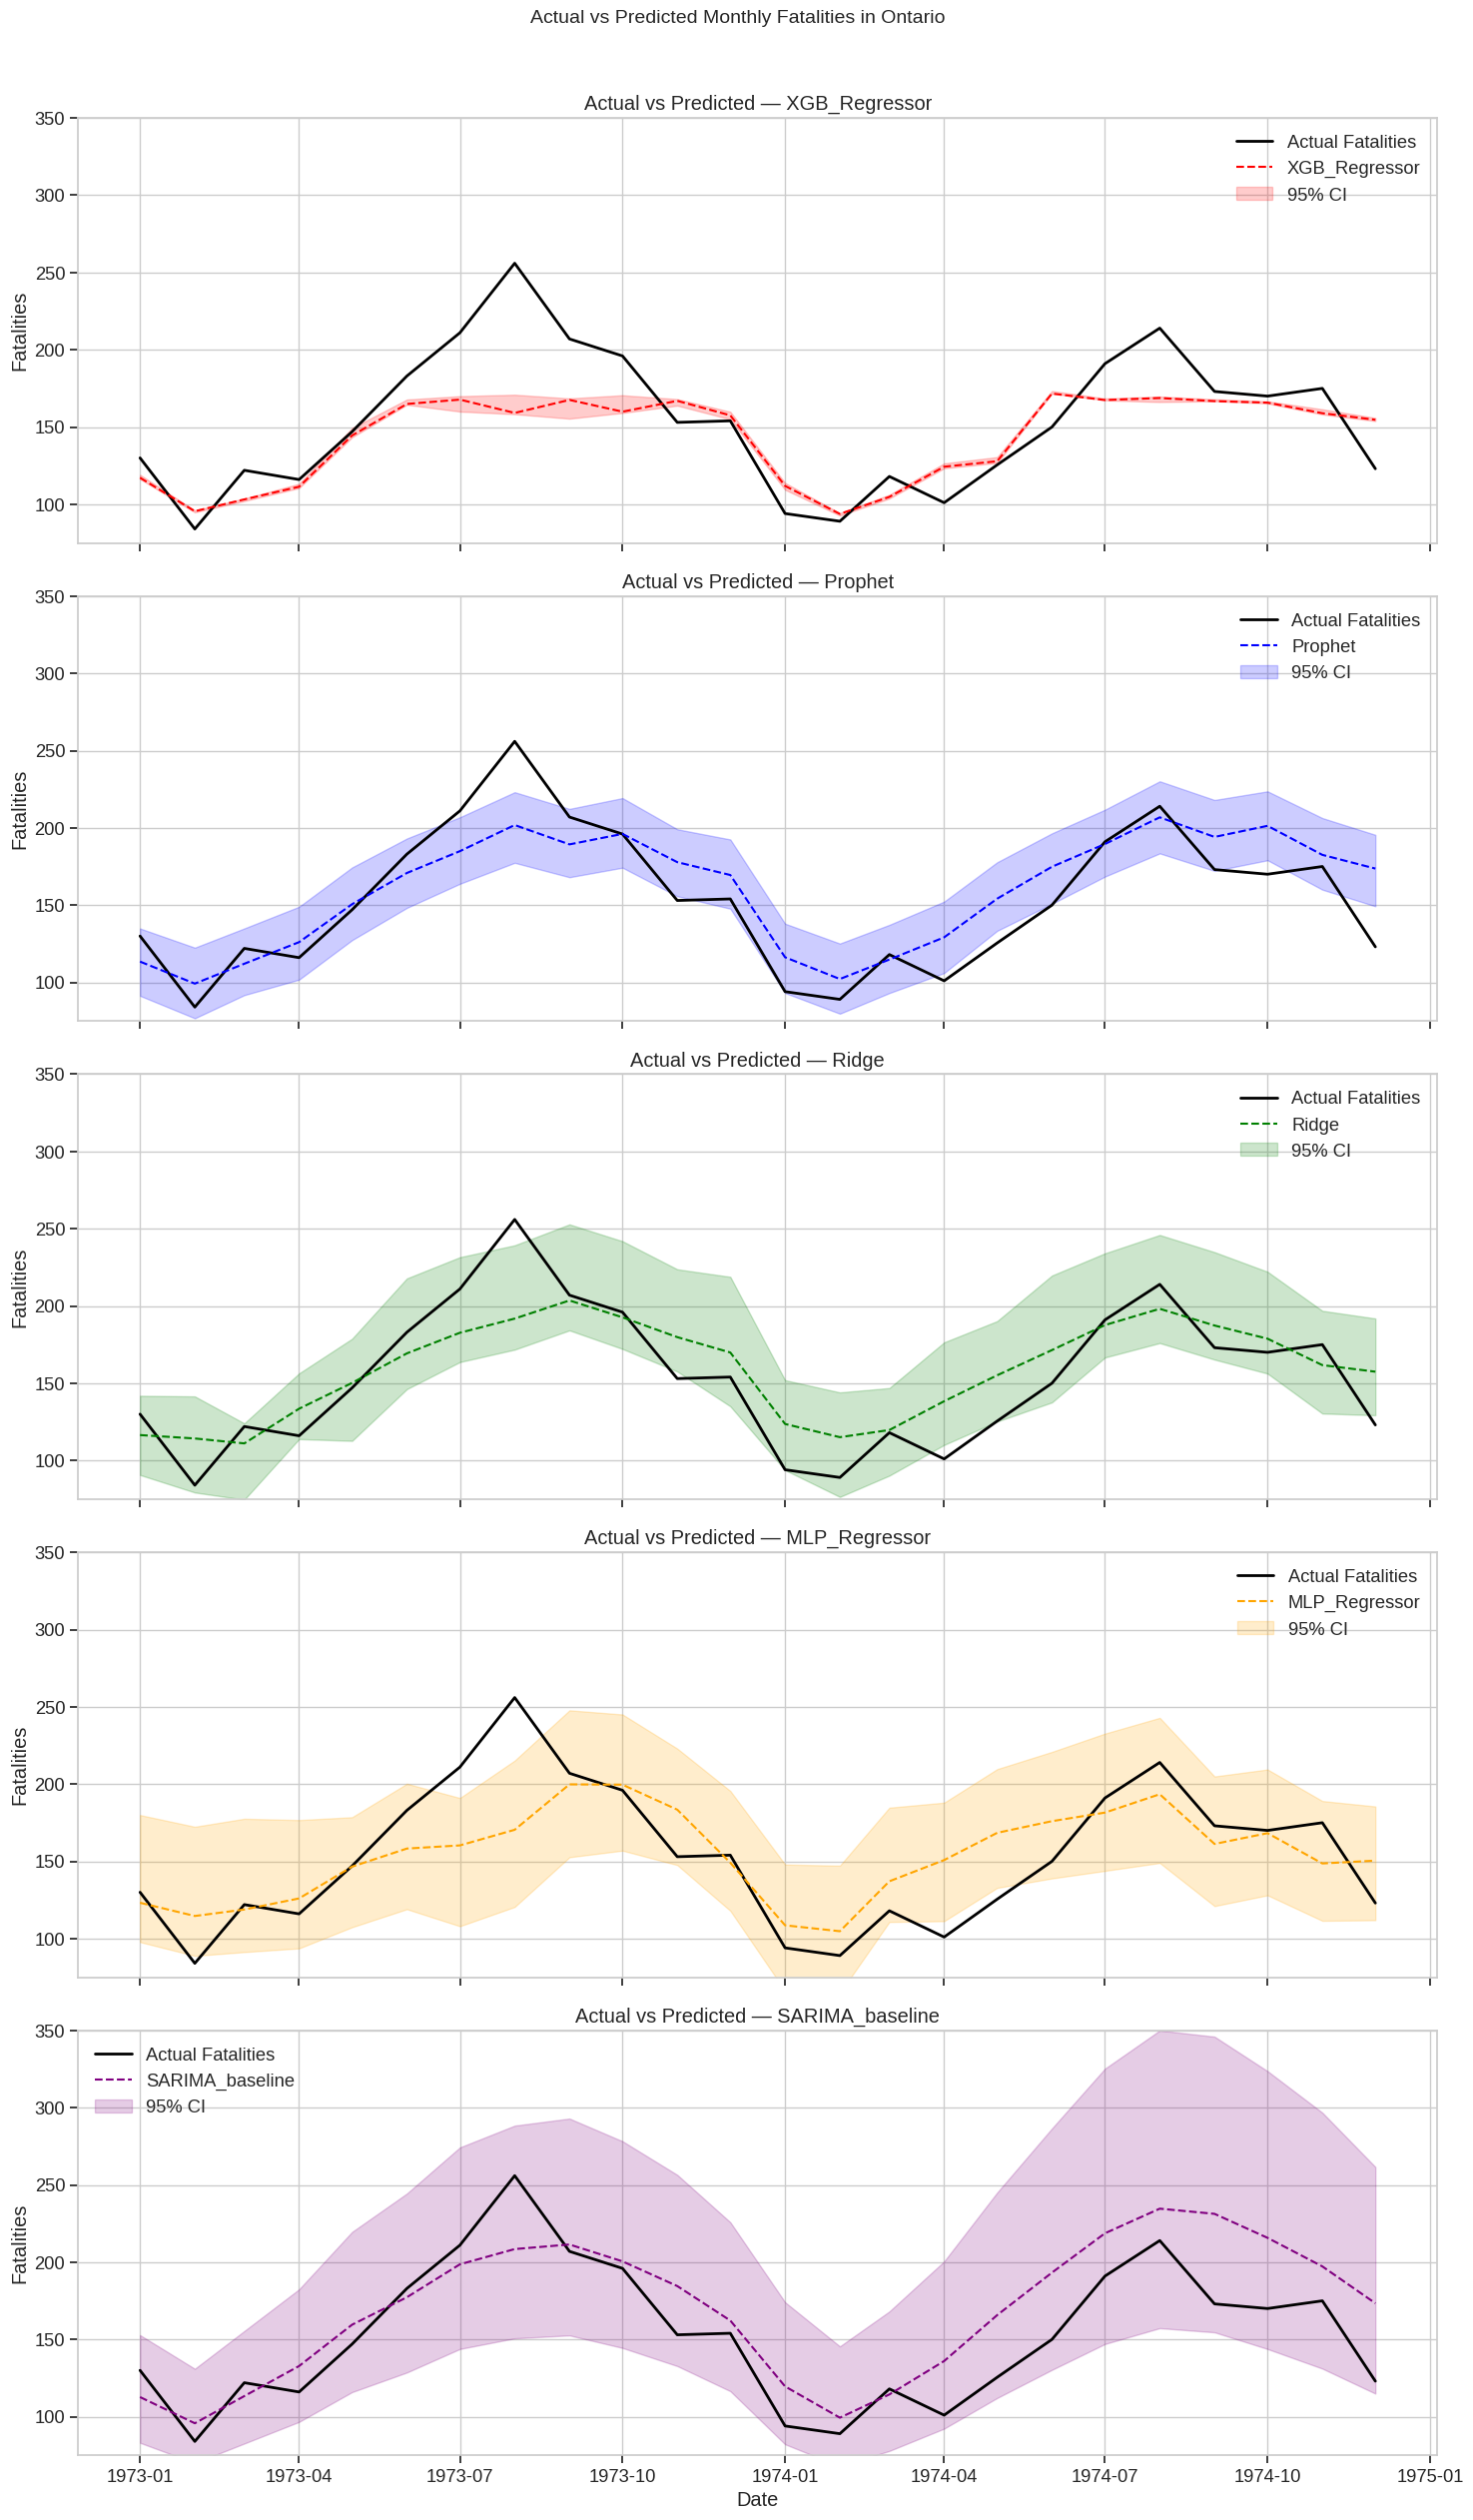

In [13]:
n_models = len(predictions_log)
fig, axes = plt.subplots(n_models, 1, figsize=(15, 5 * n_models), sharex=True)

if n_models == 1:
    axes = [axes]

colors = ['red', 'blue', 'green', 'orange', 'purple']

predictions_log = dict(
    sorted(predictions_log.items(), key=lambda x: x[1]["mape"])
)

for ax, (model_name, preds_log), color in zip(axes, predictions_log.items(), colors):
    preds_actual = preds_log["prediction"]
    lower_actual = preds_log["lower_bound"]
    upper_actual = preds_log["upper_bound"]

    ax.plot(X_test.index, y_test, label='Actual Fatalities', color='black', linewidth=2)
    ax.plot(test_df.index, preds_actual, label=model_name, linestyle='--', color=color)
    ax.fill_between(y_test_index, lower_actual, upper_actual, color=color, alpha=0.2, label='95% CI')

    ax.set_title(f'Actual vs Predicted — {model_name}')
    ax.set_ylabel('Fatalities')
    ax.legend()
    ax.grid(True)
    ax.set_ylim(75, 350)
axes[-1].set_xlabel('Date')
plt.suptitle('Actual vs Predicted Monthly Fatalities in Ontario', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 4.1 Interpretation of Results

All four ML models outperform the SARIMA baseline (MAPE 16.31%), confirming that the engineered features successfully capture the underlying structure of the series.

**XGBoost** achieves the best MAPE (12.97%) and by far the tightest confidence intervals (MPIW 4.32), showing strong point-forecast accuracy. However, its plots reveal a systematic failure on summer peaks — particularly in 1973–1974 — likely due to overfitting to the lower
variance of earlier years and not generalising to the increasing amplitude of the final period.

**Prophet** ranks second on MAPE (13.08%) and produces visually smooth, well-shaped forecasts that track both the seasonal cycle and the upward trend. Notably, it achieves this without any lag or rolling features — operating purely on the time index — which makes its performance
especially remarkable. Its wider confidence intervals (MPIW 45.07) reflect greater uncertainty, but they are better calibrated than those of Ridge or MLP.

**Ridge Regression** (MAPE 14.39%) demonstrates that a linear combination of the engineered features already explains most of the signal, validating the feature engineering choices made in Section 2. Its confidence intervals (MPIW 65.20) are reasonably wide but consistently envelope
the true values.

**MLP Regressor** shows the weakest performance among ML models (MAPE 15.11%, MPIW 82.26). Despite extensive hyperparameter search, the network struggled to converge reliably and its wide, diffuse intervals suggest high uncertainty. Given the small dataset size (~144 training samples), the MLP likely lacks sufficient data to generalise well.

Regarding prediction interval width (MPIW), there is a clear trade-off: XGBoost produces overconfident intervals that undercover the actual values, while MLP and Ridge skew in the opposite direction. Prophet strikes the best balance between sharpness and coverage.